
Filtered data saved to Excel: ./Output-files/260503-S1-HMEC-indODP-COMBINED_filtered_max_dia.xlsx
       Name (NA)  Corrected length  Elli.R1/R2
1    A_left-DSM1        550.619542       1.396
3    A_left-DSM2        459.977978       2.148
5    A_left-DSM3       1229.840000       2.028
6    A_left-DSM4        621.475313       1.263
8    A_left-DSM5        489.525141       1.864
10   A_left-DSM6        359.117752       1.497
12   A_left-DSM7        554.853800       1.456
14   A_left-DSM8       2963.250000       3.351
18  A_right-DSM1       3219.830000       2.958
19  A_right-DSM2        383.634469       2.496


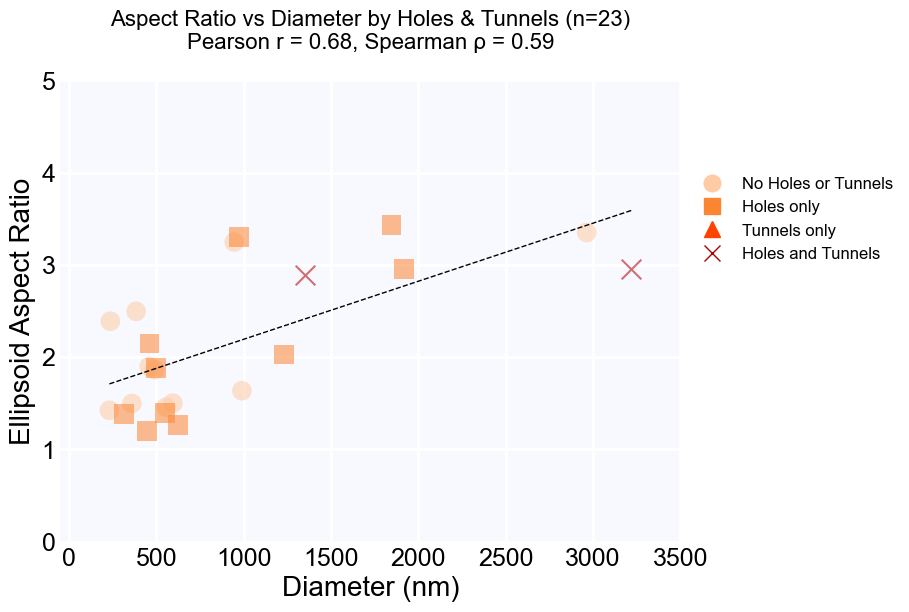

C:\Users\Notapple\AppData\Local\Temp\ipykernel_12060\1530868285.py:217: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(group[x], group[y],


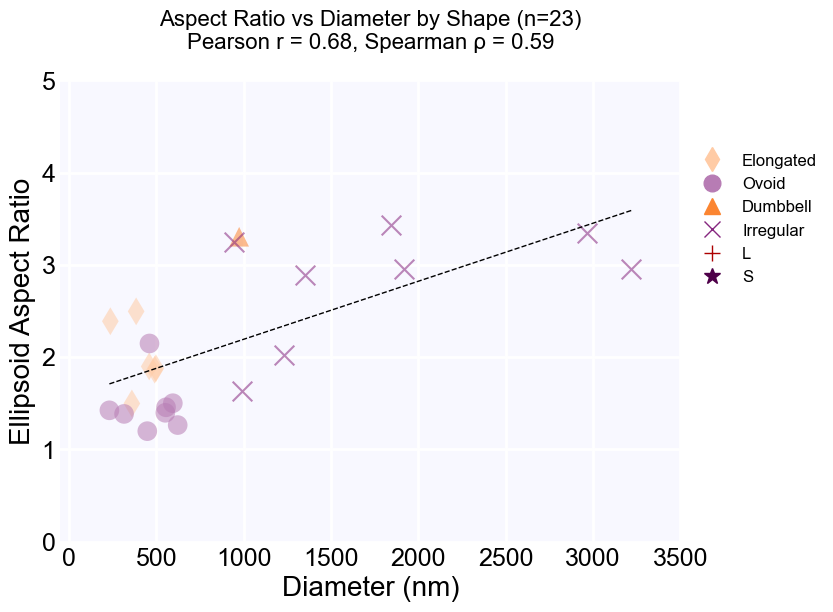

(0.6792713564528008, 0.5879446640316206)

In [4]:
# -------------------------------------------------------------------
# Cell 1.Resub: S1 acini plots (filtered for max diameter per sample)
# -------------------------------------------------------------------
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr, spearmanr
import numpy as np
import matplotlib
import matplotlib.lines as mlines

# ------------------------------
# User Settings
# ------------------------------
input_fileS1 = "260503-S1-HMEC-indODP-COMBINED.csv"
new_input_fileS1 = input_fileS1.replace(".csv", "")
substr = os.path.splitext(os.path.basename(input_fileS1))[0]
output_dir = "./Output-files/"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Font sizes
# ------------------------------
title_fontsize = 16
axis_fontsize = 20
tick_fontsize = 18
legend_fontsize = 12

# ------------------------------
# Set fonts to be editable in Illustrator
# ------------------------------
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.titlesize": title_fontsize,
    "axes.labelsize": axis_fontsize,
    "xtick.labelsize": tick_fontsize,
    "ytick.labelsize": tick_fontsize,
    "legend.fontsize": legend_fontsize,
})

# Scatter transparency
alpha_val = 0.55

# Legend
legend_pos = (1, 0.7)
marker_size = 12

# Axis limits
x_limit_R12_DIA = (-50, 3500)
y_limit_R12_DIA = (-0.01, 5)

# Holes & Tunnels
holes_colors = ["#FFCBA5", "#FB8531", "#FF4300", "#AD0000"]
holes_color_map = {0: holes_colors[0], 1: holes_colors[1], 2: holes_colors[2], 3: holes_colors[3]}
holes_marker_map = {0: "o", 1: "s", 2: "^", 3: "x"}
holes_handles = [
    mlines.Line2D([], [], color=holes_colors[0], marker="o", linestyle="None", markersize=marker_size, label="No Holes or Tunnels"),
    mlines.Line2D([], [], color=holes_colors[1], marker="s", linestyle="None", markersize=marker_size, label="Holes only"),
    mlines.Line2D([], [], color=holes_colors[2], marker="^", linestyle="None", markersize=marker_size, label="Tunnels only"),
    mlines.Line2D([], [], color=holes_colors[3], marker="x", linestyle="None", markersize=marker_size, label="Holes and Tunnels"),
]

# Shapes
shapes_colors = ["#FFCBA5", "#B77CB4", "#FB8531", "#86277F", "#AD0000", "#4E0049"]
shapes_color_map = {
    "Elongated":  shapes_colors[0],
    "Ovoid":      shapes_colors[1],
    "Dumbbell":   shapes_colors[2],
    "Irregular":  shapes_colors[3],
    "L":          shapes_colors[4],
    "S":          shapes_colors[5],
}
shapes_marker_map = {
    "Elongated":  "d",
    "Ovoid":      "o",
    "Dumbbell":   "^",
    "Irregular":  "x",
    "L":          "+",
    "S":          "*",
}
shapes_handles = [
    mlines.Line2D([], [], color=shapes_colors[0], marker="d", linestyle="None", markersize=marker_size, label="Elongated"),
    mlines.Line2D([], [], color=shapes_colors[1], marker="o", linestyle="None", markersize=marker_size, label="Ovoid"),
    mlines.Line2D([], [], color=shapes_colors[2], marker="^", linestyle="None", markersize=marker_size, label="Dumbbell"),
    mlines.Line2D([], [], color=shapes_colors[3], marker="x", linestyle="None", markersize=marker_size, label="Irregular"),
    mlines.Line2D([], [], color=shapes_colors[4], marker="+", linestyle="None", markersize=marker_size, label="L"),
    mlines.Line2D([], [], color=shapes_colors[5], marker="*", linestyle="None", markersize=marker_size, label="S"),
]


# Plot background color
background_color = "ghostwhite"

# ------------------------------
# Axis label display names
# ------------------------------
axis_label_map = {
    "Corrected length": "Diameter (nm)",
    "Elli.R1/R2": "Ellipsoid Aspect Ratio",
}

# ------------------------------
# Columns
# ------------------------------
diameter_col = "Corrected length"
ellir1r2_col = "Elli.R1/R2"
sample_col = "Name (NA)"
ht_col = "Holes_and_tunnels"
shapes_col = "Shapes"

# ------------------------------
# Load data
# ------------------------------
df = pd.read_csv(input_fileS1)

# ------------------------------
# Filter to max diameter per sample
# ------------------------------
if sample_col in df.columns:
    idx = df.groupby(sample_col)[diameter_col].idxmax()
    df_filtered = df.loc[idx].copy()
else:
    df_filtered = df.copy()

# ------------------------------
# Save filtered data (max diameter per Name) to Excel
# ------------------------------
excel_output_path = os.path.join(output_dir, f"{new_input_fileS1}_filtered_max_dia.xlsx")
cols_to_exportS1 = [sample_col, diameter_col, ellir1r2_col]
df_filtered[cols_to_exportS1].to_excel(excel_output_path, index=False)
print(f"\nFiltered data saved to Excel: {excel_output_path}")
print(df_filtered[cols_to_exportS1].head(10))

# ------------------------------
# Plotting function: Holes & Tunnels
# ------------------------------
def plot_scatter_simple(data, x, y, title, filename,
                        xlim=None, ylim=None,
                        background_color="#FFFFFF"):

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_facecolor(background_color)

    for ht_val, group in data.groupby(ht_col):
        if ht_val not in holes_color_map:
            continue
        marker = holes_marker_map[ht_val]
        color = holes_color_map[ht_val]
        if marker == "x":
            ax.scatter(group[x], group[y],
                       color=color, marker=marker,
                       s=200, alpha=alpha_val, zorder=2)
        else:
            ax.scatter(group[x], group[y],
                       facecolor=color, edgecolor="none", marker=marker,
                       s=200, alpha=alpha_val, zorder=2)

    valid = data[[x, y]].dropna()
    slope = intercept = np.nan
    if not valid.empty:
        slope, intercept, _, _, _ = linregress(valid[x], valid[y])
        x_vals = np.array([valid[x].min(), valid[x].max()])
        ax.plot(x_vals, intercept + slope*x_vals, linestyle='--', color="black", linewidth=1, zorder=3)

    n_samples = len(valid)
    if n_samples >= 3:
        r_pearson, _ = pearsonr(valid[x], valid[y])
        rho_spearman, _ = spearmanr(valid[x], valid[y])
    else:
        r_pearson = rho_spearman = np.nan

    x_label = axis_label_map.get(x, x)
    y_label = axis_label_map.get(y, y)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(
        f"{title} (n={n_samples})\n"
        f"Pearson r = {r_pearson:.2f}, Spearman ρ = {rho_spearman:.2f}\n"
    )

    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.tick_params(axis='both', which='both', length=0)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='-', color='white', linewidth=2, alpha=1)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.legend(handles=holes_handles, loc="center left", bbox_to_anchor=legend_pos, fontsize=legend_fontsize, frameon=False)

    for ext in ["png", "pdf"]:
        fig.savefig(os.path.join(output_dir, f"{filename}.{ext}"), dpi=300, bbox_inches="tight")

    plt.show(fig)
    return r_pearson, rho_spearman

# ------------------------------
# Plotting function: Shapes
# ------------------------------
def plot_scatter_shapes(data, x, y, title, filename,
                        xlim=None, ylim=None,
                        background_color="#FFFFFF"):

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_facecolor(background_color)

    for shape_val, group in data.groupby(shapes_col):
        if shape_val not in shapes_color_map:
            continue
        marker = shapes_marker_map[shape_val]
        color = shapes_color_map[shape_val]
        ax.scatter(group[x], group[y],
                   facecolor=color, edgecolor="none", marker=marker,
                   s=200, alpha=alpha_val, zorder=2)

    valid = data[[x, y]].dropna()
    slope = intercept = np.nan
    if not valid.empty:
        slope, intercept, _, _, _ = linregress(valid[x], valid[y])
        x_vals = np.array([valid[x].min(), valid[x].max()])
        ax.plot(x_vals, intercept + slope*x_vals, linestyle='--', color="black", linewidth=1, zorder=3)

    n_samples = len(valid)
    if n_samples >= 3:
        r_pearson, _ = pearsonr(valid[x], valid[y])
        rho_spearman, _ = spearmanr(valid[x], valid[y])
    else:
        r_pearson = rho_spearman = np.nan

    x_label = axis_label_map.get(x, x)
    y_label = axis_label_map.get(y, y)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(
        f"{title} (n={n_samples})\n"
        f"Pearson r = {r_pearson:.2f}, Spearman ρ = {rho_spearman:.2f}\n"
    )

    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.tick_params(axis='both', which='both', length=0)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='-', color='white', linewidth=2, alpha=1)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.legend(handles=shapes_handles, loc="center left", bbox_to_anchor=legend_pos, fontsize=legend_fontsize, frameon=False)

    for ext in ["png", "pdf"]:
        fig.savefig(os.path.join(output_dir, f"{filename}.{ext}"), dpi=300, bbox_inches="tight")

    plt.show(fig)
    return r_pearson, rho_spearman

# ------------------------------
# Plot: Holes & Tunnels — R1/R2 vs Diameter
# ------------------------------
plot_scatter_simple(
    df_filtered,
    x=diameter_col,
    y=ellir1r2_col,
    title="Aspect Ratio vs Diameter by Holes & Tunnels",
    filename=substr + "-EllAspRat_vs_Dia-Corr",
    xlim=x_limit_R12_DIA,
    ylim=y_limit_R12_DIA,
    background_color=background_color
)

# ------------------------------
# Plot: Shapes — R1/R2 vs Diameter
# ------------------------------
plot_scatter_shapes(
    df_filtered,
    x=diameter_col,
    y=ellir1r2_col,
    title="Aspect Ratio vs Diameter by Shape",
    filename=substr + "-EllAspRat_vs_Dia-Shapes",
    xlim=x_limit_R12_DIA,
    ylim=y_limit_R12_DIA,
    background_color=background_color
)



Filtered data saved to Excel: ./Output-files/260222-airway-ind-measurements-sorted_filtered_max_dia_byClass.xlsx
    Cell class_Sorted                         Name (NA)  Feret Max (nm)  \
311                MT   251214-DSM-Airway-s0-v19-ROI-10      218.621094   
339                MG  251214-DSM-Airway-s0-v19-ROI-100      177.235575   
364                MG  251214-DSM-Airway-s0-v19-ROI-101      187.082474   
366                MG  251214-DSM-Airway-s0-v19-ROI-102      172.046727   
415                MM  251214-DSM-Airway-s0-v19-ROI-103      366.199437   
58                 MM  251214-DSM-Airway-s0-v19-ROI-104       89.995909   
408                MM  251214-DSM-Airway-s0-v19-ROI-105      337.886825   
23                 MM  251214-DSM-Airway-s0-v19-ROI-106      103.440619   
386                MM  251214-DSM-Airway-s0-v19-ROI-107      214.007320   
389                MM  251214-DSM-Airway-s0-v19-ROI-108      216.302821   

     MATCHED_Elli.R1/R2  MATCHED_Elli.R1/R3  Sphericity  \
3

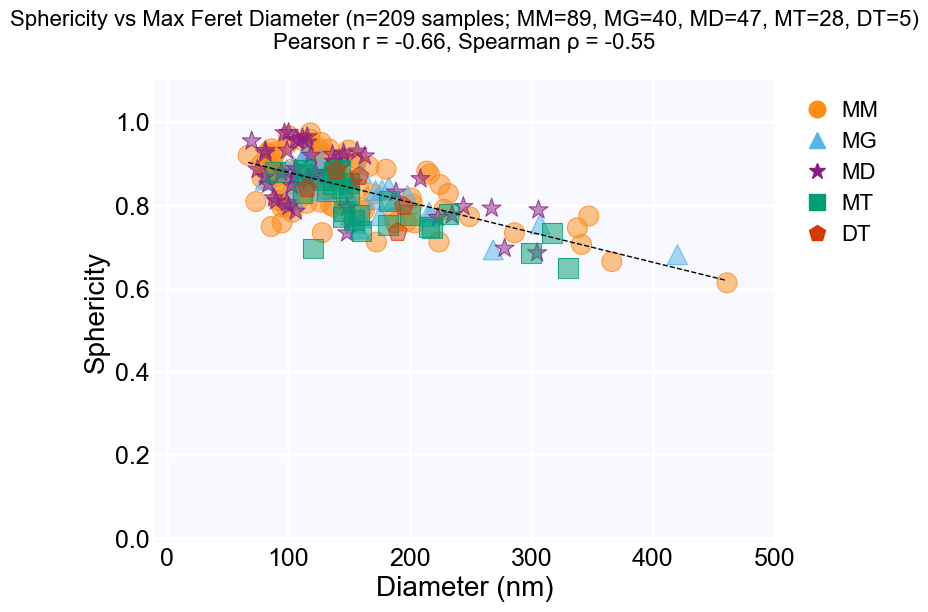

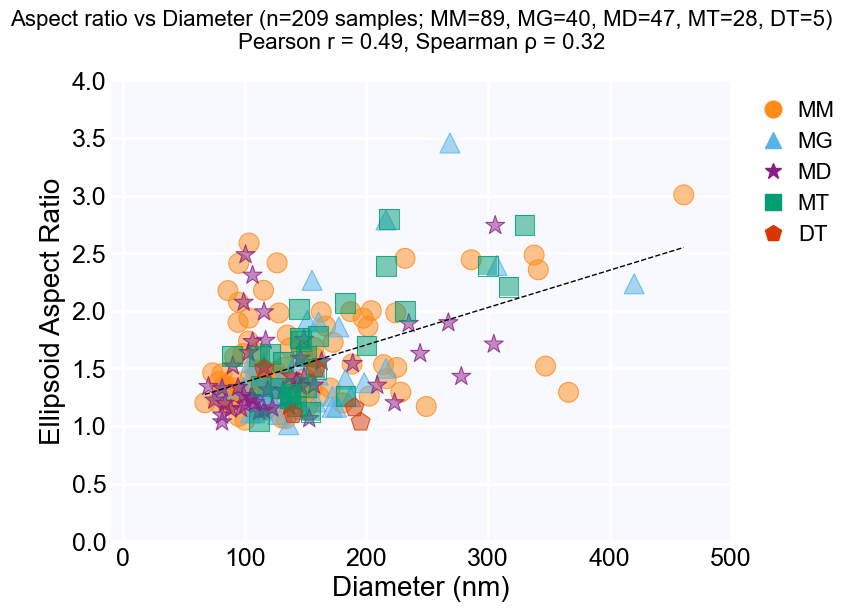

(0.49495217264254365, 0.3222226384862167)

In [9]:
# ------------------------------------------------------------------------------------------
# Cell 2: Airway plots multiple cell-cell new classes (filtered for max diameter per sample)
# Datapoints by Cell class
# ------------------------------------------------------------------------------------------
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr, spearmanr
import matplotlib.lines as mlines
import numpy as np
import matplotlib

# ------------------------------
# User Settings
# ------------------------------
input_fileAIR = "260222-airway-ind-measurements-sorted.csv"
new_input_fileAIR = input_fileAIR.replace(".csv", "")
substr = os.path.splitext(os.path.basename(input_fileAIR))[0]
output_dir = "./Output-files/"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Font sizes
# ------------------------------
title_fontsize = 16
axis_fontsize = 20
tick_fontsize = 18
legend_fontsize = 16

# ------------------------------
# Set fonts for Illustrator
# ------------------------------
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.titlesize": title_fontsize,
    "axes.labelsize": axis_fontsize,
    "xtick.labelsize": tick_fontsize,
    "ytick.labelsize": tick_fontsize,
    "legend.fontsize": legend_fontsize,
})

# ------------------------------
# Scatter transparency
# ------------------------------
alpha_val = 0.5
edge_alpha_val = 0.8

# ------------------------------
# Legend
# ------------------------------
cellclass_legend_pos = (0.55, 0.85)
marker_size = 12  # for legend only

# ------------------------------
# Axis limits
# ------------------------------
x_limit_S_MFD = (-10, 500)
y_limit_S_MFD = (-0.01, 1.1)
x_limit_R12_DIA = (-10, 500)
y_limit_R12_DIA = (-0.01, 4)

# ------------------------------
# Plot background color
# ------------------------------
background_color = "ghostwhite"

# ------------------------------
# Axis label display names
# ------------------------------
axis_label_map = {
    "Feret Max (nm)": "Diameter (nm)",
    "MATCHED_Elli.R1/R2": "Ellipsoid Aspect Ratio",
}

# ------------------------------
# Columns
# ------------------------------
source_col = "Cell class_Sorted"
sample_col = "Name (NA)"
diameter_col = "Feret Max (nm)"
ellir1r2_col = "MATCHED_Elli.R1/R2"
sphericity_col = "Sphericity"
com_col = "Center Of Mass Index Z_Sorted"

# ------------------------------
# Load data
# ------------------------------
df = pd.read_csv(input_fileAIR)

# ------------------------------
# Filter to max diameter per sample
# ------------------------------
if sample_col in df.columns:
    idx = df.groupby(sample_col)[diameter_col].idxmax()
    df_filtered = df.loc[idx].copy()
else:
    df_filtered = df.copy()

# ------------------------------
# Save filtered Excel (original)
# ------------------------------
excel_output_path = os.path.join(output_dir, f"{new_input_fileAIR}_filtered_max_dia_byClass.xlsx")
cols_to_exportAIR = [source_col, sample_col, diameter_col, ellir1r2_col, ellir1r3_col, sphericity_col, com_col]
df_filtered[cols_to_exportAIR].to_excel(excel_output_path, index=False)
print(f"\nFiltered data saved to Excel: {excel_output_path}")
print(df_filtered[cols_to_exportAIR].head(10))

# ------------------------------------------------------------------------------------------
# EXCEL-DRIVEN CELL CLASS HANDLING (COLORS + MARKERS)
# ------------------------------------------------------------------------------------------
df_filtered["Group"] = df_filtered[source_col].str.lower().str.strip()
unique_classes = df_filtered["Group"].dropna().unique()
preferred_order = ["mm", "mg", "md", "mt", "dt"]
cellclass_plot_order = [cls for cls in preferred_order if cls in unique_classes]

cellclass_colors = ["#ff8b18", "#56b4e9", "#8a1d84", "#009e73", "#d83800"]
cellclass_color_map = {cls: cellclass_colors[i] for i, cls in enumerate(cellclass_plot_order)}
cellclass_markers = ["o", "^", "*", "s", "p"]
cellclass_marker_map = {cls: cellclass_markers[i] for i, cls in enumerate(cellclass_plot_order)}
cellclass_handles = [
    mlines.Line2D([], [], color=cellclass_color_map[cls], marker=cellclass_marker_map[cls],
                  linestyle="None", markersize=marker_size, label=cls.upper())
    for cls in cellclass_plot_order
]

# ------------------------------------------------------------------------------------------
# PLOTTING FUNCTION
# ------------------------------------------------------------------------------------------
def plot_scatter(data, x, y, color_map, marker_map, plot_order,
                 title, filename, legend_handles, alpha=0.6,
                 legend_pos=cellclass_legend_pos, xlim=None, ylim=None,
                 background_color="#FFFFFF"):

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_facecolor(background_color)

    # Scatter by class
    for cls in plot_order:
        subset = data[data["Group"] == cls]
        # Face
        ax.scatter(subset[x], subset[y], color=color_map[cls], marker=marker_map[cls],
                   s=200, alpha=alpha_val, edgecolor="none", zorder=10+plot_order.index(cls))
        # Edge
        ax.scatter(subset[x], subset[y], color="None", marker=marker_map[cls],
                   s=205, alpha=edge_alpha_val, edgecolor=color_map[cls], linewidth=0.8, zorder=11+plot_order.index(cls))

    # Regression line (whole dataset)
    valid = data[[x, y]].dropna()
    if not valid.empty:
        slope, intercept, _, _, _ = linregress(valid[x], valid[y])
        x_vals = np.array([valid[x].min(), valid[x].max()])
        ax.plot(x_vals, intercept + slope*x_vals, color="black", linestyle="--", linewidth=1, zorder=20)

        # Correlations
        r_pearson, _ = pearsonr(valid[x], valid[y])
        rho_spearman, _ = spearmanr(valid[x], valid[y])
    else:
        r_pearson = rho_spearman = np.nan

    # Sample counts
    counts = {cls: len(data[data["Group"]==cls]) for cls in plot_order}
    count_string = ", ".join([f"{cls.upper()}={counts[cls]}" for cls in counts])

    # Labels and title
    x_label = axis_label_map.get(x, x)
    y_label = axis_label_map.get(y, y)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f"{title} (n={len(data)} samples; {count_string})\n"
                 f"Pearson r = {r_pearson:.2f}, Spearman ρ = {rho_spearman:.2f}\n")

    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.tick_params(axis='both', which='major', length=0)
    ax.grid(True, linestyle='-', color='white', linewidth=2, alpha=1, zorder=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.legend(handles=legend_handles, loc="center left", handletextpad=0.1,
              bbox_to_anchor=(1, 0.8), frameon=False)

    # Save
    for ext in ["png","pdf"]:
        fig.savefig(os.path.join(output_dir, f"{filename}.{ext}"), dpi=300, bbox_inches="tight")

    plt.show()
    return r_pearson, rho_spearman

# ------------------------------------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------------------------------------
plot_scatter(
    df_filtered,
    x=diameter_col,
    y=sphericity_col,
    color_map=cellclass_color_map,
    marker_map=cellclass_marker_map,
    plot_order=cellclass_plot_order,
    title="Sphericity vs Max Feret Diameter",
    filename=substr + "-Spher_vs_MFD_Corr",
    legend_handles=cellclass_handles,
    alpha=alpha_val,
    legend_pos=cellclass_legend_pos,
    xlim=x_limit_S_MFD,
    ylim=y_limit_S_MFD,
    background_color=background_color
)

plot_scatter(
    df_filtered,
    x=diameter_col,
    y=ellir1r2_col,
    color_map=cellclass_color_map,
    marker_map=cellclass_marker_map,
    plot_order=cellclass_plot_order,
    title="Aspect ratio vs Diameter",
    filename=substr + "-Dia_vs_AspRat_Corr",
    legend_handles=cellclass_handles,
    alpha=alpha_val,
    legend_pos=cellclass_legend_pos,
    xlim=x_limit_R12_DIA,
    ylim=y_limit_R12_DIA,
    background_color=background_color
)



Filtered data saved to Excel: ./Output-files/251224-airway-ind-measurements-MCC-MCC-border1_filtered_max_dia.xlsx
             Name (NA)  Feret Max (nm)  Center Of Mass Index Z  CoMZ_norm
31  251214-Air ROI 104       89.995909                     443        194
14  251214-Air ROI 106      103.440619                     391        142
59  251214-Air ROI 142      112.246921                     609        360
36  251214-Air ROI 165       87.156533                     490        241
47  251214-Air ROI 171      101.960779                     518        269
57  251214-Air ROI 182      114.453921                     713        464
49  251214-Air ROI 183       87.746541                     552        303
9   251214-Air ROI 184       94.842177                     498        249
27  251214-Air ROI 185       91.639831                     477        228
18  251214-Air ROI 186       81.239295                     435        186


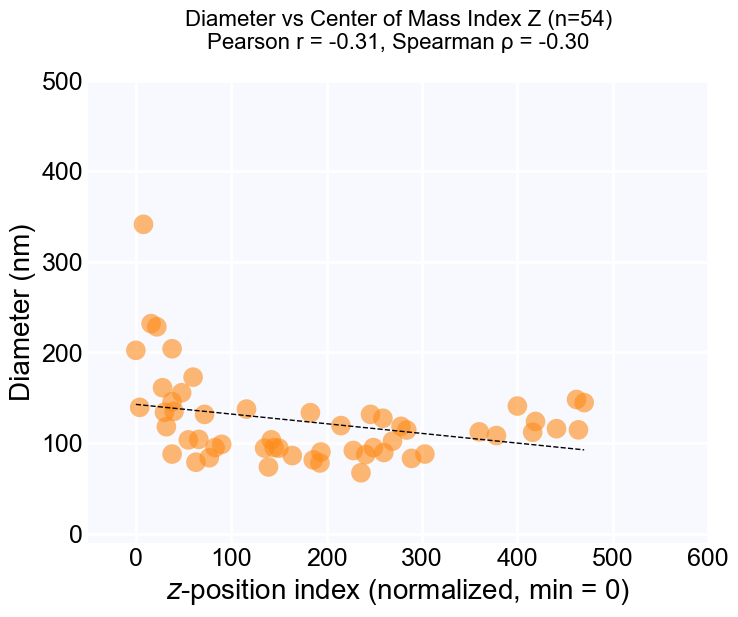

In [7]:
# ------------------------------------------------------------------
# Cell 2B.1: Airway plots (filtered for max diameter per sample)
# MCC-MCC Border 1. Pearson + Spearman
# ------------------------------------------------------------------
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr, spearmanr
import numpy as np
import matplotlib

# ------------------------------
# User Settings
# ------------------------------
input_fileCC = "251224-airway-ind-measurements-MCC-MCC-border1.csv"
new_input_fileCC = input_fileCC.replace(".csv", "")
substr = os.path.splitext(os.path.basename(input_fileCC))[0]
output_dir = "./Output-files/"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Font sizes
# ------------------------------
title_fontsize = 16
axis_fontsize = 20
tick_fontsize = 18
legend_fontsize = 12

# ------------------------------
# Set fonts to be editable in Illustrator
# ------------------------------
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.titlesize": title_fontsize,
    "axes.labelsize": axis_fontsize,
    "xtick.labelsize": tick_fontsize,
    "ytick.labelsize": tick_fontsize,
    "legend.fontsize": legend_fontsize,
})

# Scatter point transparency
alpha_val = 0.6

# Axis limits
x_limit_CoMZ_MFD = (-50, 600)
y_limit_CoMZ_MFD = (-10, 500)

# Plot colors
background_color = "ghostwhite"
color_mapCC = "#ff8b18"

# ------------------------------
# Columns
# ------------------------------
diameter_col = "Feret Max (nm)"
CoMZ_col = "Center Of Mass Index Z"
sample_col = "Name (NA)"

# ------------------------------
# Load data
# ------------------------------
df = pd.read_csv(input_fileCC)

# ------------------------------
# Filter to max diameter per sample
# ------------------------------
if sample_col in df.columns:
    idx = df.groupby(sample_col)[diameter_col].idxmax()
    df_filtered = df.loc[idx].copy()
else:
    df_filtered = df.copy()

# ------------------------------
# Helper functions
# ------------------------------
def normalize_min_zero(series):
    return series - series.min()

# ------------------------------
# Normalize CoMZ so min = 0 for plotting
# ------------------------------
if CoMZ_col in df_filtered.columns:
    df_filtered['CoMZ_norm'] = normalize_min_zero(df_filtered[CoMZ_col])
    
# ------------------------------
# Save filtered data (existing Excel)
# ------------------------------
excel_output_path = os.path.join(output_dir, f"{new_input_fileCC}_filtered_max_dia.xlsx")
cols_to_exportCC = [sample_col, diameter_col, CoMZ_col, 'CoMZ_norm']
df_filtered[cols_to_exportCC].to_excel(excel_output_path, index=False)
print(f"\nFiltered data saved to Excel: {excel_output_path}")
print(df_filtered[cols_to_exportCC].head(10))

    
# ------------------------------
# Plotting function
# ------------------------------
def plot_diameter_vs_z(data, diameter_col, z_col, title, filename,
                       xlim=None, ylim=None, alpha=0.6, background_color="ghostwhite"):

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_facecolor(background_color)
    
    # Scatter plot (normalized z for plotting)
    ax.scatter(data['CoMZ_norm'], data[diameter_col], 
               color=color_mapCC, s=200, alpha=alpha, edgecolor="none", zorder=2)
    
    # Compute correlations on raw units
    valid = data[[z_col, diameter_col]].dropna()
    if not valid.empty:
        r_pearson, _ = pearsonr(valid[z_col], valid[diameter_col])
        rho_spearman, _ = spearmanr(valid[z_col], valid[diameter_col])

        # Linear regression line for visualization
        # Normalize x for plotting
        x_norm = normalize_min_zero(valid[z_col])

        # Linear regression (still on RAW data — correct)
        slope, intercept, _, _, _ = linregress(valid[z_col], valid[diameter_col])

        # Regression line evaluated at raw x, plotted at normalized x
        x_line_raw = np.linspace(valid[z_col].min(), valid[z_col].max(), 100)
        y_line = intercept + slope * x_line_raw
        x_line_norm = normalize_min_zero(x_line_raw)

        ax.plot(x_line_norm, y_line, 
                color="black", linestyle="--", linewidth=1, zorder=20)

    else:
        r_pearson = rho_spearman = np.nan

    # Labels and title
    n_samples = len(valid)
    ax.set_xlabel(r"$z$-position index (normalized, min = 0)")
    ax.set_ylabel("Diameter (nm)")
    ax.set_title(f"{title} (n={n_samples})\n"
                 f"Pearson r = {r_pearson:.2f}, Spearman ρ = {rho_spearman:.2f}\n")

    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.tick_params(axis='both', which='both', length=0)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='-', color='white', linewidth=2, alpha=1, zorder=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Save figure
    for ext in ["png", "pdf"]:
        fig.savefig(os.path.join(output_dir, f"{filename}.{ext}"),
                    dpi=300, bbox_inches="tight")
    plt.show()

    return r_pearson, rho_spearman

# ---------------------------------------------------
# Plot: Diameter vs Center of Mass Index Z
# ---------------------------------------------------
r_pearson, rho_spearman = plot_diameter_vs_z(
    df_filtered,
    diameter_col=diameter_col,
    z_col=CoMZ_col,
    title="Diameter vs Center of Mass Index Z",
    filename=substr + "-MFD_vs_Z-Corr",
    xlim=x_limit_CoMZ_MFD,
    ylim=y_limit_CoMZ_MFD,
    alpha=alpha_val,
    background_color=background_color
)



Filtered data saved to Excel: ./Output-files/251224-airway-ind-measurements-MCC-DC-border2_filtered_max_dia.xlsx
             Name (NA)  Feret Max (nm)  Center Of Mass Index Z  CoMZ_norm
25  251214-Air ROI 174      118.738079                     688        315
29  251214-Air ROI 175      108.154424                     671        298
12  251214-Air ROI 176      102.941149                     567        194
18  251214-Air ROI 177       98.965751                     507        134
7   251214-Air ROI 178       81.209367                     449         76
46  251214-Air ROI 179      188.664460                     373          0
6   251214-Air ROI 180       98.968268                     704        331
2   251214-Air ROI 193       74.824423                     524        151
4   251214-Air ROI 195       83.635290                     698        325
50   251214-Air ROI 20      304.741422                     402         29


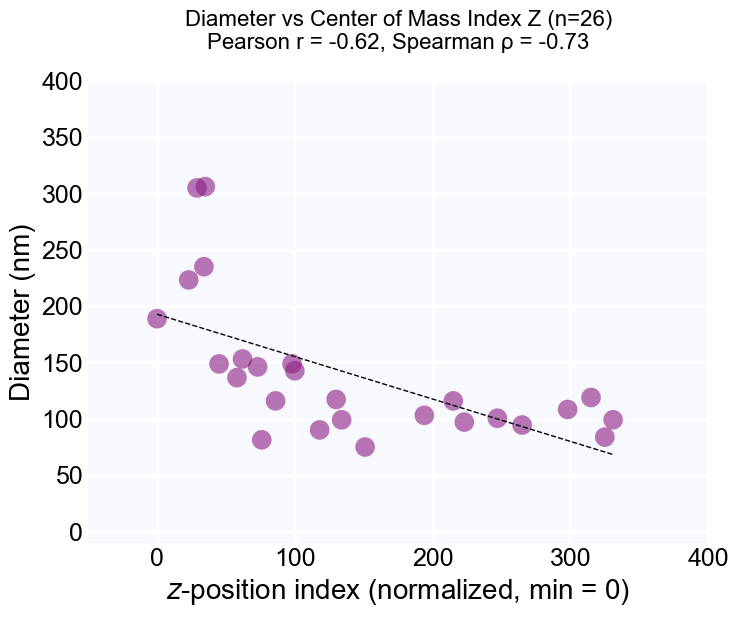

In [6]:
# ------------------------------------------------------------------
# Cell 2B.2: Airway plots (filtered for max diameter per sample)
# MCC-DC Border 2. Pearson + Spearman
# ------------------------------------------------------------------
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr, spearmanr
import numpy as np
import matplotlib

# ------------------------------
# User Settings
# ------------------------------
input_fileCC = "251224-airway-ind-measurements-MCC-DC-border2.csv"
new_input_fileCC = input_fileCC.replace(".csv", "")
substr = os.path.splitext(os.path.basename(input_fileCC))[0]
output_dir = "./Output-files/"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Font sizes
# ------------------------------
title_fontsize = 16
axis_fontsize = 20
tick_fontsize = 18
legend_fontsize = 12

# ------------------------------
# Set fonts to be editable in Illustrator
# ------------------------------
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.titlesize": title_fontsize,
    "axes.labelsize": axis_fontsize,
    "xtick.labelsize": tick_fontsize,
    "ytick.labelsize": tick_fontsize,
    "legend.fontsize": legend_fontsize,
})

# Scatter point transparency
alpha_val = 0.6

# Axis limits
x_limit_CoMZ_MFD = (-50, 400)
y_limit_CoMZ_MFD = (-10, 400)

# Plot colors
background_color = "ghostwhite"
color_mapCC = "#8a1d84"

# ------------------------------
# Columns
# ------------------------------
diameter_col = "Feret Max (nm)"
CoMZ_col = "Center Of Mass Index Z"
sample_col = "Name (NA)"

# ------------------------------
# Load data
# ------------------------------
df = pd.read_csv(input_fileCC)

# ------------------------------
# Filter to max diameter per sample
# ------------------------------
if sample_col in df.columns:
    idx = df.groupby(sample_col)[diameter_col].idxmax()
    df_filtered = df.loc[idx].copy()
else:
    df_filtered = df.copy()

# ------------------------------
# Helper functions
# ------------------------------
def normalize_min_zero(series):
    return series - series.min()

# ------------------------------
# Normalize CoMZ so min = 0 for plotting
# ------------------------------
if CoMZ_col in df_filtered.columns:
    df_filtered['CoMZ_norm'] = normalize_min_zero(df_filtered[CoMZ_col])

# ------------------------------
# Save filtered data (existing Excel)
# ------------------------------
excel_output_path = os.path.join(output_dir, f"{new_input_fileCC}_filtered_max_dia.xlsx")
cols_to_exportCC = [sample_col, diameter_col, CoMZ_col, 'CoMZ_norm']
df_filtered[cols_to_exportCC].to_excel(excel_output_path, index=False)
print(f"\nFiltered data saved to Excel: {excel_output_path}")
print(df_filtered[cols_to_exportCC].head(10))

# ------------------------------
# Helper functions
# ------------------------------
def normalize_min_zero(series):
    return series - series.min()
    

# ------------------------------
# Plotting function
# ------------------------------
def plot_diameter_vs_z(data, diameter_col, z_col, title, filename,
                       xlim=None, ylim=None, alpha=0.6, background_color="ghostwhite"):

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_facecolor(background_color)
    
    # Scatter plot (normalized z for plotting)
    ax.scatter(data['CoMZ_norm'], data[diameter_col], 
               color=color_mapCC, s=200, alpha=alpha, edgecolor="none", zorder=2)
    
    # Compute correlations on raw units
    valid = data[[z_col, diameter_col]].dropna()
    if not valid.empty:
        r_pearson, _ = pearsonr(valid[z_col], valid[diameter_col])
        rho_spearman, _ = spearmanr(valid[z_col], valid[diameter_col])
       
        # Linear regression line for visualization
        # Normalize x for plotting
        x_norm = normalize_min_zero(valid[z_col])

        # Linear regression (still on RAW data — correct)
        slope, intercept, _, _, _ = linregress(valid[z_col], valid[diameter_col])

        # Regression line evaluated at raw x, plotted at normalized x
        x_line_raw = np.linspace(valid[z_col].min(), valid[z_col].max(), 100)
        y_line = intercept + slope * x_line_raw
        x_line_norm = normalize_min_zero(x_line_raw)

        ax.plot(x_line_norm, y_line, 
                color="black", linestyle="--", linewidth=1, zorder=20)

    else:
        r_pearson = rho_spearman = np.nan

    # Labels and title
    n_samples = len(valid)
    ax.set_xlabel(r"$z$-position index (normalized, min = 0)")
    ax.set_ylabel("Diameter (nm)")
    ax.set_title(f"{title} (n={n_samples})\n"
                 f"Pearson r = {r_pearson:.2f}, Spearman ρ = {rho_spearman:.2f}\n")

    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.tick_params(axis='both', which='both', length=0)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='-', color='white', linewidth=2, alpha=1, zorder=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Save figure
    for ext in ["png", "pdf"]:
        fig.savefig(os.path.join(output_dir, f"{filename}.{ext}"),
                    dpi=300, bbox_inches="tight")
    plt.show()

    return r_pearson, rho_spearman

# ---------------------------------------------------
# Plot: Diameter vs Center of Mass Index Z
# ---------------------------------------------------
r_pearson, rho_spearman = plot_diameter_vs_z(
    df_filtered,
    diameter_col=diameter_col,
    z_col=CoMZ_col,
    title="Diameter vs Center of Mass Index Z",
    filename=substr + "-MFD_vs_Z-Corr",
    xlim=x_limit_CoMZ_MFD,
    ylim=y_limit_CoMZ_MFD,
    alpha=alpha_val,
    background_color=background_color
)



Filtered data saved to Excel: ./Output-files/260503-DSM2-DSM3-indODP-COMBINED_filtered_max_dia.xlsx
                                    Source.Name       Name (NA)  \
57  260501-DSM2-NKB_DSM_measurements-ind_AB.csv   DSM2-NKB-DSM1   
62  260501-DSM2-NKB_DSM_measurements-ind_AB.csv  DSM2-NKB-DSM10   
65  260501-DSM2-NKB_DSM_measurements-ind_AB.csv  DSM2-NKB-DSM11   
70  260501-DSM2-NKB_DSM_measurements-ind_AB.csv  DSM2-NKB-DSM12   
74  260501-DSM2-NKB_DSM_measurements-ind_AB.csv  DSM2-NKB-DSM13   
77  260501-DSM2-NKB_DSM_measurements-ind_AB.csv  DSM2-NKB-DSM14   
81  260501-DSM2-NKB_DSM_measurements-ind_AB.csv  DSM2-NKB-DSM15   
85  260501-DSM2-NKB_DSM_measurements-ind_AB.csv  DSM2-NKB-DSM16   
89  260501-DSM2-NKB_DSM_measurements-ind_AB.csv  DSM2-NKB-DSM17   
94  260501-DSM2-NKB_DSM_measurements-ind_AB.csv  DSM2-NKB-DSM18   

    Corrected length  Elli.R1/R2  Holes_and_tunnels  #Radial_filaments  \
57        156.275365       1.747                  0                  0   
62        205

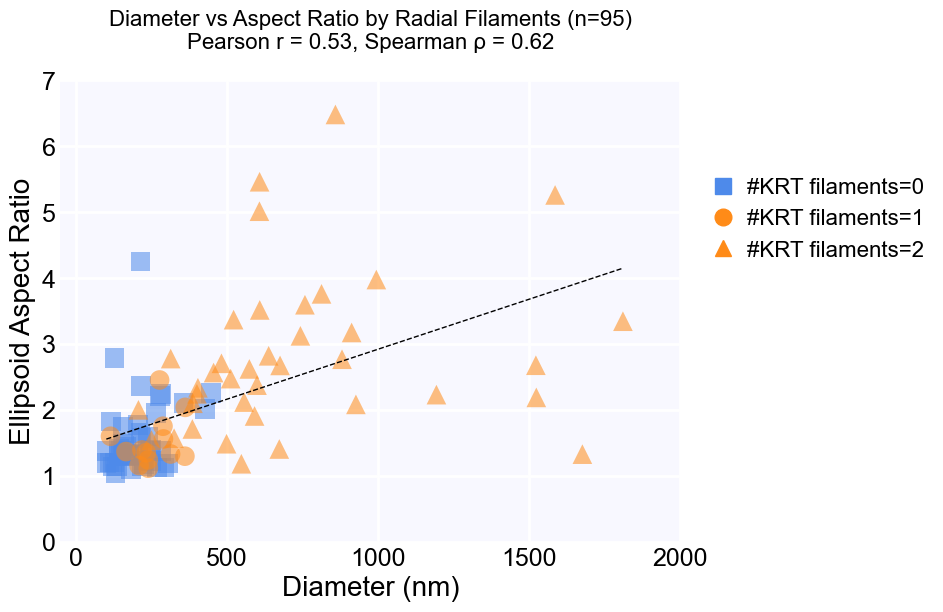

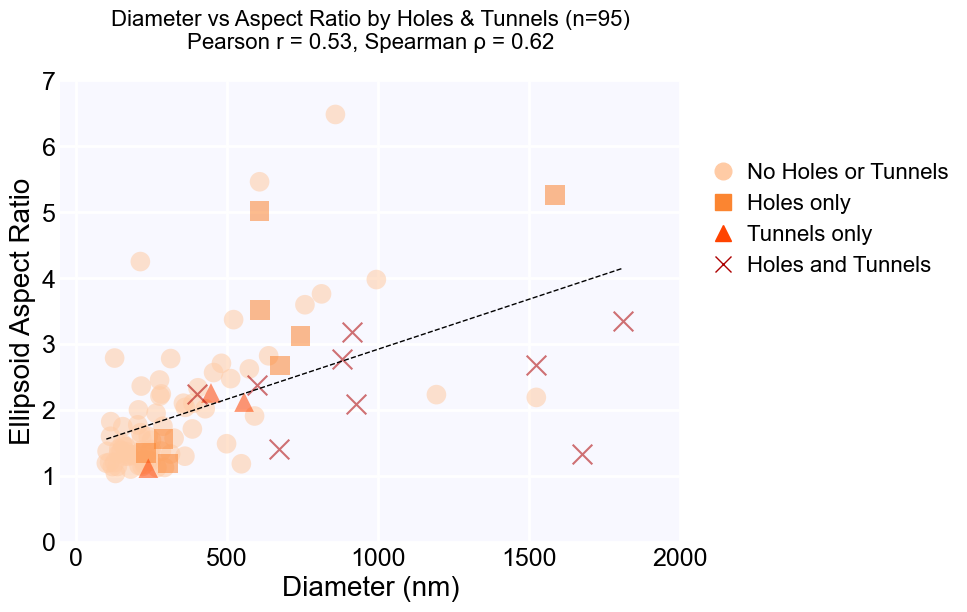

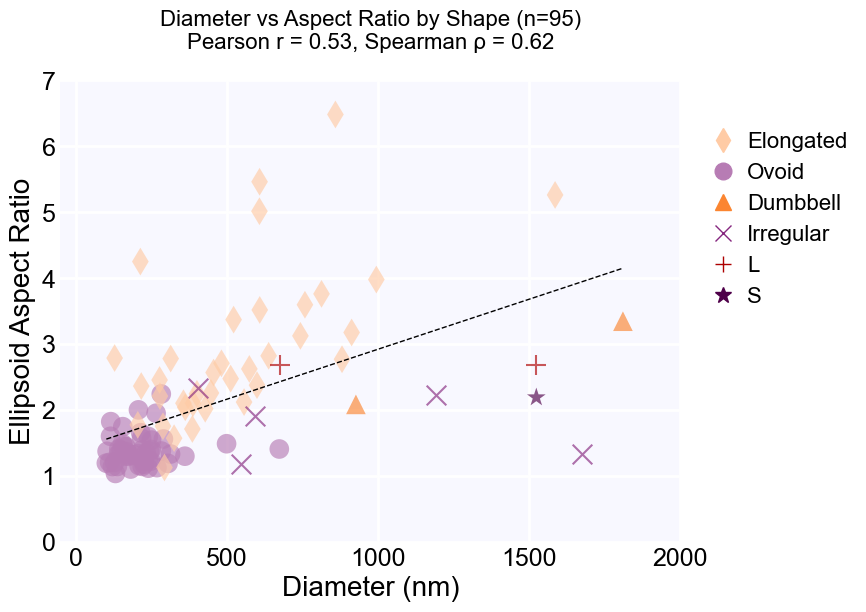

(0.5301429407796494, 0.6222887898151582)

In [5]:
# ---------------------------------------------------------------
# Cell 3.Resub: A431 DSMs (filtered for max diameter per sample)
# ---------------------------------------------------------------
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr, spearmanr
import matplotlib.lines as mlines
import numpy as np
import matplotlib

# ------------------------------
# User Settings
# ------------------------------
input_fileA431 = "260503-DSM2-DSM3-indODP-COMBINED.csv"
new_input_fileA431 = input_fileA431.replace(".csv", "")
substr = os.path.splitext(os.path.basename(input_fileA431))[0]
output_dir = "./Output-files/"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Font sizes (edit these to change all plots)
# ------------------------------
title_fontsize = 16
axis_fontsize = 20
tick_fontsize = 18
legend_fontsize = 16

# ------------------------------
# Set fonts to be editable in Illustrator
# ------------------------------
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.titlesize": title_fontsize,
    "axes.labelsize": axis_fontsize,
    "xtick.labelsize": tick_fontsize,
    "ytick.labelsize": tick_fontsize,
    "legend.fontsize": legend_fontsize,
})

# Scatter point transparency
alpha_val = 0.55
alpha_val_shape = 0.65

# Legend
legend_pos = (1, 0.7)
marker_size = 12

# Axis limits
x_limit_R12_DIA = (-50, 2000)
y_limit_R12_DIA = (-0.01, 7)

# Plot background color
background_color = "ghostwhite"

# ------------------------------
# Axis label display names
# ------------------------------
axis_label_map = {
    "Corrected length": "Diameter (nm)",
    "Elli.R1/R2": "Ellipsoid Aspect Ratio",
}

# ------------------------------
# Columns
# ------------------------------
source_col = "Source.Name"
name_col = "Name (NA)"
diameter_col = "Corrected length"
ellir1r2_col = "Elli.R1/R2"
fil_col = "#Radial_filaments"
ht_col = "Holes_and_tunnels"
shapes_col = "Shapes"
substrings_to_find = ["DSM2-NKB", "DSM2-SEZ", "DSM3-COMBINED"]

# ------------------------------
# Load and filter data
# ------------------------------
df = pd.read_csv(input_fileA431)
filtered_list = []

for sub in substrings_to_find:
    mask = df[source_col].astype(str).str.contains(sub, case=False, na=False)
    sub_df = df[mask].copy()
    if sub_df.empty:
        continue
    sub_df["Dataset"] = sub
    idx = sub_df.groupby(name_col)[diameter_col].idxmax()
    filtered_list.append(sub_df.loc[idx])

filtered_max_df = pd.concat(filtered_list)

# ------------------------------
# Save filtered Excel (original)
# ------------------------------
excel_output_path = os.path.join(output_dir, f"{new_input_fileA431}_filtered_max_dia.xlsx")
cols_to_export = [source_col, name_col, diameter_col, ellir1r2_col, ht_col, fil_col, shapes_col]
filtered_max_df[cols_to_export].to_excel(excel_output_path, index=False)
print(f"\nFiltered data saved to Excel: {excel_output_path}")
print(filtered_max_df[cols_to_export].head(10))


# ------------------------------
# Plotting function
# ------------------------------
def plot_scatter(data, x, y, color_map, marker_map, title, legend_handles,
                 filename, alpha=0.6, legend_pos=(1.02, 0.5),
                 xlim=None, ylim=None,
                 background_color="#FFFFFF"):

    fig, ax = plt.subplots(figsize=(8, 6))
    col_name = list(color_map.keys())[0]
    ax.set_facecolor(background_color)

    # Scatter points
    for val in data[col_name].unique():
        subset = data[data[col_name] == val]
        marker = marker_map[val]
        if marker in ["x", "+", "|", "_"]:
            ax.scatter(subset[x], subset[y], color=color_map[col_name][val],
                       marker=marker, s=200, alpha=alpha, zorder=2)
        else:
            ax.scatter(subset[x], subset[y], facecolor=color_map[col_name][val],
                       marker=marker, s=200, alpha=alpha, edgecolor="none", zorder=2)

    # Regression line (whole dataset)
    valid = data[[x, y]].dropna()
    if not valid.empty:
        slope, intercept, _, _, _ = linregress(valid[x], valid[y])
        x_vals = np.array([valid[x].min(), valid[x].max()])
        ax.plot(x_vals, intercept + slope*x_vals, color="black", linestyle="--", linewidth=1, zorder=20)

        r_pearson, _ = pearsonr(valid[x], valid[y])
        rho_spearman, _ = spearmanr(valid[x], valid[y])
    else:
        r_pearson = rho_spearman = np.nan

    # Labels and title
    n_samples = data[name_col].nunique()
    x_label = axis_label_map.get(x, x)
    y_label = axis_label_map.get(y, y)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f"{title} (n={n_samples})\n"
                 f"Pearson r = {r_pearson:.2f}, Spearman ρ = {rho_spearman:.2f}\n")

    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.tick_params(axis='both', which='both', length=0)
    ax.grid(True, linestyle='-', color='white', linewidth=2, alpha=1, zorder=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.legend(handles=legend_handles, loc="center left", bbox_to_anchor=legend_pos, handletextpad=0.1,
               frameon=False)

    # Save
    for ext in ["png", "pdf"]:
        fig.savefig(os.path.join(output_dir, f"{filename}.{ext}"), dpi=300, bbox_inches="tight")

    plt.show()
    return r_pearson, rho_spearman

# ------------------------------
# Color/marker maps: Filaments
# ------------------------------
fil_color_map = {fil_col: {0: "#4E8AEA", 1: "#FF8B18", 2: "#FF8B18"}}
fil_marker_map = {0: "s", 1: "o", 2: "^"}
filament_handles = [
    mlines.Line2D([], [], color="#4E8AEA", marker="s", linestyle="None", markersize=marker_size, label="#KRT filaments=0"),
    mlines.Line2D([], [], color="#FF8B18", marker="o", linestyle="None", markersize=marker_size, label="#KRT filaments=1"),
    mlines.Line2D([], [], color="#FF8B18", marker="^", linestyle="None", markersize=marker_size, label="#KRT filaments=2"),
]

# ------------------------------
# Color/marker maps: Holes & Tunnels
# ------------------------------
holes_colors = ["#FFCBA5", "#FB8531", "#FF4300", "#AD0000"]
holes_color_map = {ht_col: {0: holes_colors[0], 1: holes_colors[1], 2: holes_colors[2], 3: holes_colors[3]}}
holes_marker_map = {0: "o", 1: "s", 2: "^", 3: "x"}
holes_handles = [
    mlines.Line2D([], [], color=holes_colors[0], marker="o", linestyle="None", markersize=marker_size, label="No Holes or Tunnels"),
    mlines.Line2D([], [], color=holes_colors[1], marker="s", linestyle="None", markersize=marker_size, label="Holes only"),
    mlines.Line2D([], [], color=holes_colors[2], marker="^", linestyle="None", markersize=marker_size, label="Tunnels only"),
    mlines.Line2D([], [], color=holes_colors[3], marker="x", linestyle="None", markersize=marker_size, label="Holes and Tunnels"),
]

# ------------------------------
# Color/marker maps: Shapes
# ------------------------------
shapes_colors = ["#FFCBA5", "#B77CB4", "#FB8531", "#86277F", "#AD0000", "#4E0049"]
shapes_color_map = {shapes_col: {
    "Elongated":  shapes_colors[0],
    "Ovoid":      shapes_colors[1],
    "Dumbbell":   shapes_colors[2],
    "Irregular":  shapes_colors[3],
    "L":          shapes_colors[4],
    "S":          shapes_colors[5],
}}
shapes_marker_map = {
    "Elongated":  "d",
    "Ovoid":      "o",
    "Dumbbell":   "^",
    "Irregular":  "x",
    "L":          "+",
    "S":          "*",
}
shapes_handles = [
    mlines.Line2D([], [], color=shapes_colors[0], marker="d", linestyle="None", markersize=marker_size, label="Elongated"),
    mlines.Line2D([], [], color=shapes_colors[1], marker="o", linestyle="None", markersize=marker_size, label="Ovoid"),
    mlines.Line2D([], [], color=shapes_colors[2], marker="^", linestyle="None", markersize=marker_size, label="Dumbbell"),
    mlines.Line2D([], [], color=shapes_colors[3], marker="x", linestyle="None", markersize=marker_size, label="Irregular"),
    mlines.Line2D([], [], color=shapes_colors[4], marker="+", linestyle="None", markersize=marker_size, label="L"),
    mlines.Line2D([], [], color=shapes_colors[5], marker="*", linestyle="None", markersize=marker_size, label="S"),
]


# ------------------------------
# Plot 1: Filaments — Diameter vs Aspect Ratio
# ------------------------------
plot_scatter(
    filtered_max_df,
    x=diameter_col, y=ellir1r2_col,
    color_map=fil_color_map, marker_map=fil_marker_map,
    title="Diameter vs Aspect Ratio by Radial Filaments",
    legend_handles=filament_handles,
    filename=substr + "-Dia_vs_AspRat_Fil-Corr",
    alpha=alpha_val, legend_pos=legend_pos,
    xlim=x_limit_R12_DIA, ylim=y_limit_R12_DIA,
    background_color=background_color
)

# ------------------------------
# Plot 2: Holes — Diameter vs Aspect Ratio
# ------------------------------
plot_scatter(
    filtered_max_df,
    x=diameter_col, y=ellir1r2_col,
    color_map=holes_color_map, marker_map=holes_marker_map,
    title="Diameter vs Aspect Ratio by Holes & Tunnels",
    legend_handles=holes_handles,
    filename=substr + "-Dia_vs_AspRat_Holes-Corr",
    alpha=alpha_val, legend_pos=legend_pos,
    xlim=x_limit_R12_DIA, ylim=y_limit_R12_DIA,
    background_color=background_color
)

# ------------------------------
# Plot 3: Shapes — Diameter vs Aspect Ratio
# ------------------------------
plot_scatter(
    filtered_max_df,
    x=diameter_col, y=ellir1r2_col,
    color_map=shapes_color_map, marker_map=shapes_marker_map,
    title="Diameter vs Aspect Ratio by Shape",
    legend_handles=shapes_handles,
    filename=substr + "-Dia_vs_AspRat_Shapes-Corr",
    alpha=alpha_val_shape, legend_pos=legend_pos,
    xlim=x_limit_R12_DIA, ylim=y_limit_R12_DIA,
    background_color=background_color
)



Filtered rows: 95

Shape counts:
Shapes
Ovoid        49
Elongated    36
Irregular     5
Dumbbell      2
L             2
S             1
Name: count, dtype: int64

Filtered data saved to:
./Output-files//260503-A431_ODP_by_Shapes.xlsx


C:\Users\Notapple\AppData\Local\Temp\ipykernel_22708\2794564145.py:362: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Notapple\AppData\Local\Temp\ipykernel_22708\2794564145.py:380: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Notapple\AppData\Local\Temp\ipykernel_22708\2794564145.py:362: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Notapple\AppData\Local\Temp\ipykernel_22708\2794564145.py:380: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matpl

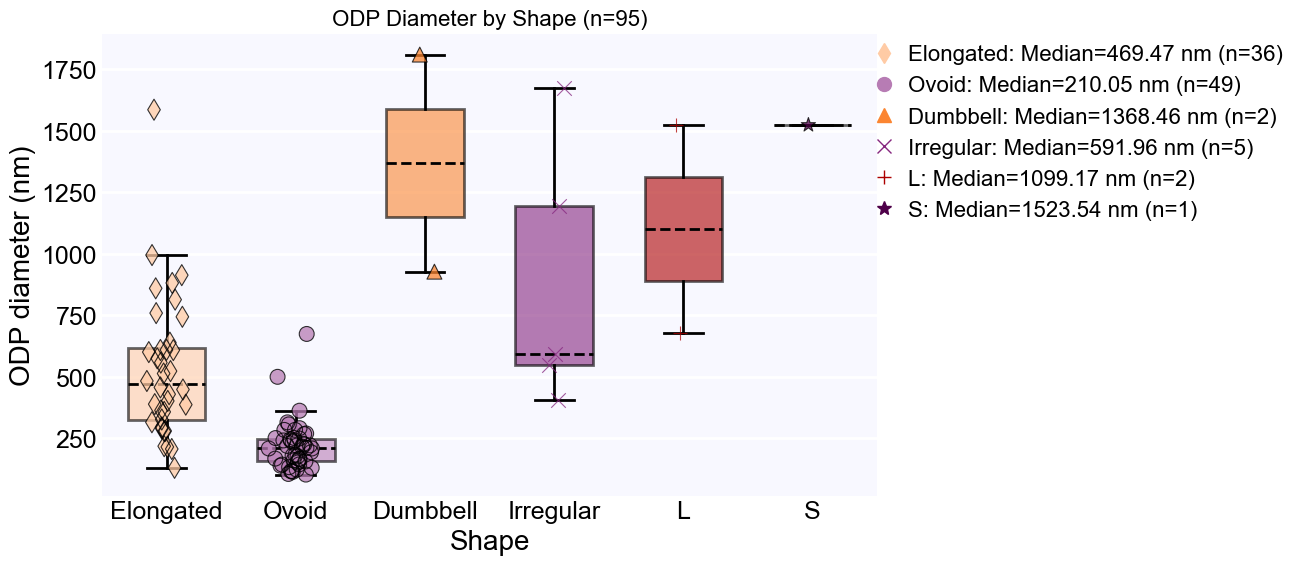


Done.


In [25]:
# ---------------------------------------------------------------
# A431 Boxplot: ODP Diameter by Shape
# Uses:
#   260503-DSM2-DSM3-indODP-COMBINED.csv
#
# X-axis = Shapes
# Y-axis = Corrected length (ODP diameter)
#
# Keeps:
#   Elongated
#   Ovoid
#   Dumbbell
#   Irregular
#   L
#   S
#
# NO remapping of L/S into Irregular
# ---------------------------------------------------------------

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ------------------------------
# User Settings
# ------------------------------
input_file = "260503-DSM2-DSM3-indODP-COMBINED.csv"

substr = "260503-A431"

output_dir = "./Output-files//"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Font sizes
# ------------------------------
title_fontsize  = 16
axis_fontsize   = 20
tick_fontsize   = 18
legend_fontsize = 16

# ------------------------------
# Set fonts editable in Illustrator
# ------------------------------
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.titlesize":  title_fontsize,
    "axes.labelsize":  axis_fontsize,
    "xtick.labelsize": tick_fontsize,
    "ytick.labelsize": tick_fontsize,
    "legend.fontsize": legend_fontsize,
})

# ------------------------------
# Plot appearance
# ------------------------------
np.random.seed(42)

jitter_width    = 0.08
plot_width      = 10
plot_height     = 6
plot_background = "ghostwhite"

point_size      = 110
edge_size       = 115

box_line_width  = 2

grid_color      = "white"
grid_linestyle  = "-"

y_axis_limits   = None

# ------------------------------
# Columns
# ------------------------------
source_col   = "Source.Name"
name_col     = "Name (NA)"
diameter_col = "Corrected length"
shapes_col   = "Shapes"

# ------------------------------
# Dataset filters
# ------------------------------
substrings_to_find = [
    "DSM2-NKB",
    "DSM2-SEZ",
    "DSM3-COMBINED"
]

# ------------------------------
# Shape colors
# ------------------------------
shapes_colors = [
    "#FFCBA5",
    "#B77CB4",
    "#FB8531",
    "#86277F",
    "#AD0000",
    "#4E0049"
]

shapes_color_map = {
    "Elongated": shapes_colors[0],
    "Ovoid":     shapes_colors[1],
    "Dumbbell":  shapes_colors[2],
    "Irregular": shapes_colors[3],
    "L":         shapes_colors[4],
    "S":         shapes_colors[5],
}

# ------------------------------
# Shape markers
# ------------------------------
shapes_marker_map = {
    "Elongated": "d",
    "Ovoid":     "o",
    "Dumbbell":  "^",
    "Irregular": "x",
    "L":         "+",
    "S":         "*",
}

# ------------------------------
# Shape order
# ------------------------------
shapes_group_order = [
    "Elongated",
    "Ovoid",
    "Dumbbell",
    "Irregular",
    "L",
    "S"
]

# ------------------------------
# Load data
# ------------------------------
df = pd.read_csv(input_file)

# Numeric conversion
df[diameter_col] = pd.to_numeric(
    df[diameter_col],
    errors="coerce"
)

# ------------------------------
# Filter datasets
# ------------------------------
filtered_list = []

for sub in substrings_to_find:

    mask = df[source_col].astype(str).str.contains(
        sub,
        case=False,
        na=False
    )

    sub_df = df[mask].copy()

    if sub_df.empty:
        continue

    sub_df["Dataset"] = sub

    # Keep max Corrected length per Name (NA)
    idx = sub_df.groupby(name_col)[diameter_col].idxmax()

    filtered_list.append(sub_df.loc[idx])

filtered_df = pd.concat(
    filtered_list,
    ignore_index=True
)

# ------------------------------
# Remove invalid rows
# ------------------------------
filtered_df = filtered_df[
    filtered_df[shapes_col].notna()
].copy()

filtered_df = filtered_df[
    filtered_df[diameter_col].notna()
].copy()

# Keep only known shapes
filtered_df = filtered_df[
    filtered_df[shapes_col].isin(shapes_group_order)
].copy()

# ------------------------------
# Print preview
# ------------------------------
print(f"\nFiltered rows: {len(filtered_df)}")

print("\nShape counts:")
print(
    filtered_df[shapes_col]
    .value_counts()
)

# ------------------------------
# Save filtered data
# ------------------------------
excel_out = os.path.join(
    output_dir,
    f"{substr}_ODP_by_Shapes.xlsx"
)

filtered_df.to_excel(
    excel_out,
    index=False
)

print(f"\nFiltered data saved to:")
print(excel_out)

# ================================================================
# Build boxplot data
# ================================================================
box_data = [
    filtered_df.loc[
        filtered_df[shapes_col] == grp,
        diameter_col
    ].dropna()

    for grp in shapes_group_order
]

counts = {
    grp: (
        filtered_df[shapes_col] == grp
    ).sum()

    for grp in shapes_group_order
}

# ================================================================
# Plot
# ================================================================
fig, ax = plt.subplots(
    figsize=(plot_width, plot_height)
)

ax.set_facecolor(plot_background)

ax.set_axisbelow(True)

ax.tick_params(
    axis="both",
    which="major",
    length=0,
    labelsize=tick_fontsize
)

# ================================================================
# Boxplot
# ================================================================
box = ax.boxplot(
    box_data,

    labels=shapes_group_order,

    patch_artist=True,

    widths=0.6,

    showfliers=False,

    medianprops=dict(
        color="black",
        linestyle="--",
        linewidth=box_line_width
    ),

    boxprops=dict(
        edgecolor="black",
        linewidth=box_line_width
    ),

    whiskerprops=dict(
        linewidth=box_line_width
    ),

    capprops=dict(
        linewidth=box_line_width
    ),
)

# ------------------------------
# Color boxes
# ------------------------------
# ------------------------------
# Color boxes + legend handles
# ------------------------------
legend_handles = []

for patch, grp in zip(
    box["boxes"],
    shapes_group_order
):

    color = shapes_color_map[grp]

    patch.set_facecolor(color)
    patch.set_alpha(0.6)

    median_val = filtered_df.loc[
        filtered_df[shapes_col] == grp,
        diameter_col
    ].median()

    legend_handles.append(
        plt.Line2D(
            [0],
            [0],

            color=color,
            lw=0,

            marker=shapes_marker_map[grp],

            markersize=10,

            label=(
                f"{grp}: "
                f"Median={median_val:.2f} nm "
                f"(n={counts[grp]})"
            )
        )
    )

# ================================================================
# Scatter points
# ================================================================
for i, grp in enumerate(
    shapes_group_order,
    start=1
):

    y_vals = filtered_df.loc[
        filtered_df[shapes_col] == grp,
        diameter_col
    ].dropna()

    x_vals = np.random.normal(
        i,
        jitter_width,
        size=len(y_vals)
    )

    color  = shapes_color_map[grp]
    marker = shapes_marker_map[grp]

    # Filled points
    ax.scatter(
        x_vals,
        y_vals,

        color=color,
        alpha=0.75,

        s=point_size,

        marker=marker,

        edgecolor="none",
        linewidth=0.8,

        zorder=10
    )

    # Black edge ring
    ax.scatter(
        x_vals,
        y_vals,

        color="none",
        alpha=0.8,

        s=edge_size,

        marker=marker,

        edgecolor="black",
        linewidth=0.8,

        zorder=11
    )

# ================================================================
# Labels
# ================================================================
ax.set_xlabel(
    "Shape",
    fontsize=axis_fontsize
)

ax.set_ylabel(
    "ODP diameter (nm)",
    fontsize=axis_fontsize
)

if y_axis_limits:
    ax.set_ylim(y_axis_limits)

ax.set_title(
    f"ODP Diameter by Shape (n={len(filtered_df)})",
    fontsize=title_fontsize
)

# ================================================================
# Legend
# ================================================================
ax.legend(
    handles=legend_handles,

    loc="upper right",

    bbox_to_anchor=(1.55, 1.02),

    handletextpad=0.1,

    frameon=False,

    fontsize=legend_fontsize
)

# ================================================================
# Grid
# ================================================================
ax.yaxis.grid(
    True,
    linestyle=grid_linestyle,
    color=grid_color,
    linewidth=2
)

ax.xaxis.grid(False)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# ================================================================
# Save
# ================================================================
for ext in ["png", "pdf"]:

    fig.savefig(
        os.path.join(
            output_dir,
            f"{substr}_ODP_by_Shapes.{ext}"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

print("\nDone.")